# Collaborative Filtering Evaluation

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy import nan

import cf
from cf import CollaborativeFiltering as CF

In [14]:
import importlib
importlib.reload(cf)

<module 'cf' from 'c:\\Users\\annik\\OneDrive\\Documents\\classes\\ds4420\\final_project\\ds4420-finalproject\\cf\\cf.py'>

## Data Preprocessing

In [5]:
df = pd.read_csv("../data/NACC_visitation_data.zip")

C:\Users\annik\AppData\Local\Temp\ipykernel_31996\845385195.py:1: DtypeWarning: Columns (0: HISPORX, 1: RACEX, 2: RACESECX, 3: RACETERX, 4: PRIMLANX, 5: INHISPOX, 6: INRACEX, 7: INRASECX, 8: INRATERX, 9: INRELTOX, 10: NACCAMX, 11: NACCAMSX, 12: NACCFMX, 13: NACCFMSX, 14: NACCOMX, 15: NACCOMSX, 16: DRUG16, 17: DRUG17, 18: DRUG18, 19: DRUG19, 20: DRUG20, 21: DRUG21, 22: DRUG22, 23: DRUG23, 24: DRUG24, 25: DRUG25, 26: DRUG26, 27: DRUG27, 28: DRUG28, 29: DRUG29, 30: DRUG30, 31: DRUG31, 32: DRUG32, 33: DRUG33, 34: DRUG34, 35: DRUG35, 36: DRUG36, 37: DRUG37, 38: DRUG38, 39: DRUG39, 40: DRUG40, 41: CVOTHRX, 42: NCOTHRX, 43: ARTHTYPX, 44: OTHSLEEX, 45: ABUSX, 46: PSYCDISX, 47: CVDIMAGX, 48: SPEECHX, 49: FACEXPX, 50: TRESTFAX, 51: TRESTRHX, 52: TRESTLHX, 53: TRESTRFX, 54: TRESTLFX, 55: TRACTRHX, 56: TRACTLHX, 57: RIGDNEX, 58: RIGDUPRX, 59: RIGDUPLX, 60: RIGDLORX, 61: RIGDLOLX, 62: TAPSRTX, 63: TAPSLFX, 64: HANDMVRX, 65: HANDMVLX, 66: HANDATRX, 67: HANDATLX, 68: LEGRTX, 69: LEGLFX, 70: ARISINGX,

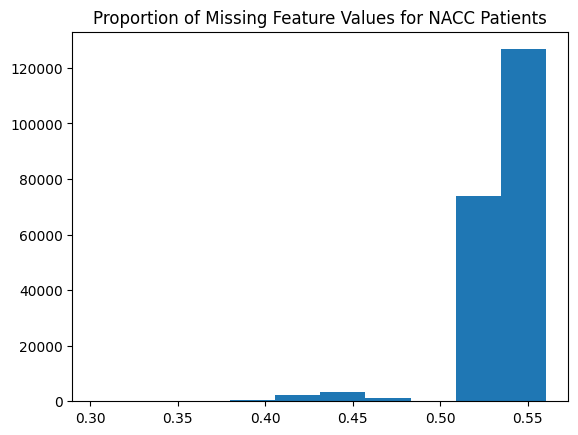

In [6]:
# inspect data sparsity -> number of missing features for each user
plt.hist(df.isna().sum(axis=1) / df.shape[1])
plt.title("Proportion of Missing Feature Values for NACC Patients")
plt.show()

In [7]:
# filter on features of interest
filtered = df[["BILLS", "TAXES", "SHOPPING", "MEALPREP", "EVENTS", "PAYATTN", "REMDATES", "TRAVEL", "MEMORY", "SPEECH", "CDRSUM", "NACCMMSE", "NACCMOCA"]]
filtered.index = df.NACCID.astype(str) + "_" + df.NACCVNUM.astype(str)

# replace null values (using provided data dictionary) with nan
filtered.NACCMMSE = filtered.NACCMMSE.replace([88, 95, 96, 97, 98, -4], nan)
filtered.NACCMOCA = filtered.NACCMOCA.replace([88, 99, -4], nan)
filtered.replace([99], nan, inplace=True)
cols = filtered.columns[:-3]
filtered[cols] = filtered[cols].astype(float)
filtered[cols] = filtered[cols].replace([8, 9, -4], np.nan)

# filter to users with at least 3 not missing values
filtered = filtered[filtered.notna().sum(axis=1) >= 3]

In [8]:
filtered.head()

,BILLS,TAXES,SHOPPING,MEALPREP,EVENTS,PAYATTN,REMDATES,TRAVEL,MEMORY,SPEECH,CDRSUM,NACCMMSE,NACCMOCA
NACC002909_1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.5,NaN,0.5,NaN,25.0
NACC002909_2,1.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,0.5,NaN,1.0,NaN,23.0
NACC002909_3,0.0,1.0,2.0,NaN,1.0,2.0,2.0,2.0,0.5,NaN,1.0,NaN,NaN
NACC003142_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,23.0
NACC003487_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,23.0


## Validation

In [16]:
# initialize model
cf = CF(data=filtered)

In [17]:
# run predictions on one user
cf.run(target="NACC002909_3", metric="cosine", k=5, mask_idx=12)

{'NACCMOCA': 26.340600473936874}

In [17]:
validation_result = cf.validate()

In [23]:
def calc_mse(row, standardize: bool = False):
    error = row["actual"] - row["pred"]
    if standardize:
        i = cf.df.columns.get_loc(row["feature"])
        error = error / cf.item_stds[i]
    return error**2

def calc_mae(row, standardize: bool = False):
    error = row["actual"] - row["pred"]
    if standardize:
        i = cf.df.columns.get_loc(row["feature"])
        error = error / cf.item_stds[i]
    return np.abs(error)

def standardize_mse(row):
    return calc_mse(row, standardize=True)

def standardize_mae(row):
    return calc_mae(row, standardize=True)

In [ ]:
validation_result["squared_error"] = validation_result.apply(standardize_mse, axis=1)
validation_result["absolute_error"] = validation_result.apply(standardize_mae, axis=1)

In [ ]:
def feature_plot(result: pd.DataFrame, save_path: str) -> None:
    
    result["squared_error"] = result.apply(standardize_mse, axis=1)
    result["absolute_error"] = result.apply(standardize_mae, axis=1)

    features = result.groupby("feature")[["squared_error", "absolute_error"]].mean().reset_index()
    features["rmse"] = features["squared_error"].apply(np.sqrt) 

    categories = features["feature"].values
    rmses = features["rmse"].values
    maes = features["absolute_error"].values
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    rmses = np.append(rmses, rmses[0])
    maes = np.append(maes, maes[0])
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rmses, marker='o', label="RMSE")
    ax.fill(angles, rmses, alpha=0.25)
    ax.plot(angles, maes, marker='o', label="MAE")
    ax.fill(angles, maes, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    # fix labels so that ones near the center don't cover plot
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        label.set_rotation(angle_deg)

        if angle_deg < 50 or 130 < angle_deg < 230 or 310 < angle_deg:
            label.set_y(label.get_position()[1] - 0.1)

    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    ax.set_title("Scaled Prediction Error for Features of Visitation Data")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

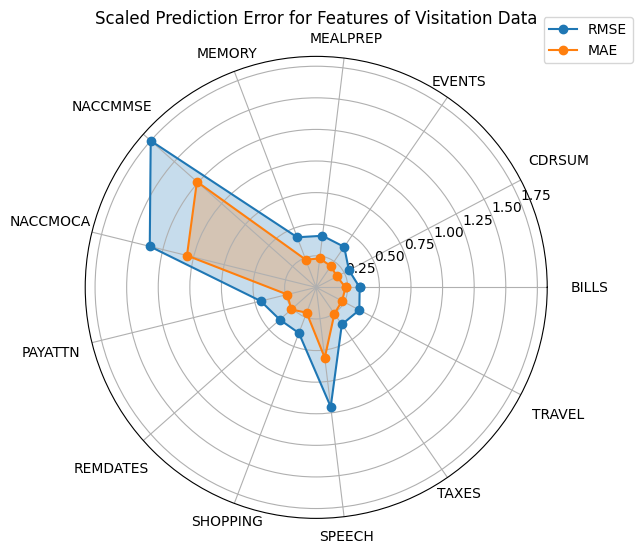

In [21]:
feature_plot(validation_result, save_path="plots/validation_feature_plot.png")

In [22]:
validation_summary = validation_result.groupby(["metric", "k"])[["squared_error", "absolute_error"]].mean().reset_index()
validation_summary["rmse"] = validation_summary["squared_error"].apply(np.sqrt)

In [23]:
print(validation_summary)

   metric   k  squared_error  absolute_error      rmse
0  cosine   5       0.372852        0.321681  0.610616
1  cosine   7       0.369852        0.318707  0.608154
2  cosine   9       0.368229        0.317290  0.606818
3  cosine  11       0.366565        0.315946  0.605446
4      l2   5       0.376105        0.320426  0.613274
5      l2   7       0.373635        0.317684  0.611257
6      l2   9       0.371398        0.315299  0.609424
7      l2  11       0.370163        0.313524  0.608410


Based on the summary of errors across all features, there isn't much difference in model performance using different hyperparameter values, specifically similarity metric and k nearest neighbors. This could be due to the fact that there are many missing values for some of the features. Choosing between 5 to 11 nearest neighbors still might have all missing values for a feature. In this case, it would default to the item mean regardless of the hyperparameter used. 

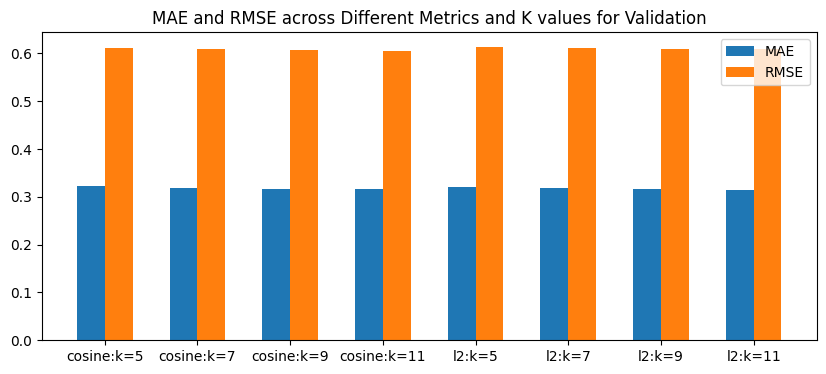

In [24]:
# plot error metrics across hyperparameter values
x = validation_summary.index
labels = validation_summary["metric"] + ":k=" + validation_summary["k"].astype(str)
width = 0.3

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, validation_summary["absolute_error"], width, label="MAE")
ax.bar(x + width/2, validation_summary["rmse"], width, label="RMSE")
ax.set_xticks(x, labels=labels)
ax.set_title("MAE and RMSE across Different Metrics and K values for Validation")
ax.legend()
plt.show()

## Evaluation

In [21]:
evaluation_result = cf.evaluate(metric="l2", k=11, sample_size=1000)

In [30]:
evaluation_result["squared_error"] = evaluation_result.apply(calc_mse, axis=1)
evaluation_result["absolute_error"] = evaluation_result.apply(calc_mae, axis=1)

In [31]:
evaluation_features = evaluation_result.groupby("feature")[["squared_error", "absolute_error"]].mean().reset_index()
evaluation_features["rmse"] = evaluation_features["squared_error"].apply(np.sqrt) 

In [ ]:
evaluation_features

,feature,squared_error,absolute_error,rmse
0,BILLS,0.183664,0.281222,0.428560
1,CDRSUM,1.770328,0.807396,1.330537
2,EVENTS,0.172040,0.219592,0.414777
3,MEALPREP,0.181569,0.239528,0.426109
4,MEMORY,0.093303,0.166954,0.305456
5,NACCMMSE,93.844044,7.288668,9.687314
6,NACCMOCA,63.478284,6.151909,7.967326
7,PAYATTN,0.160991,0.205148,0.401236
8,REMDATES,0.204726,0.294711,0.452466
9,SHOPPING,0.153368,0.216892,0.391623


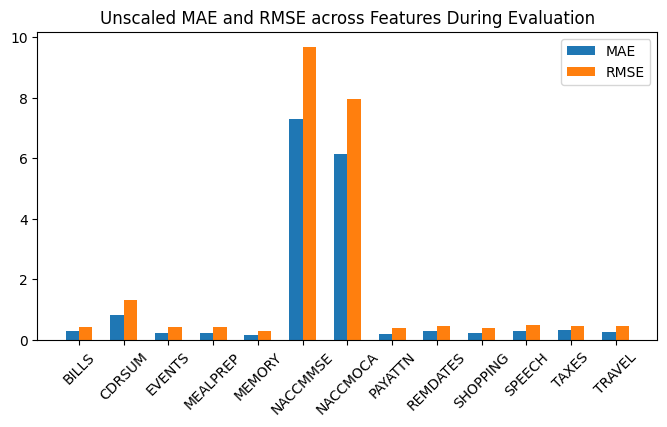

In [43]:
# plot error metrics unscaled
x = evaluation_features.index
labels = evaluation_features["feature"]
width = 0.3

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, evaluation_features["absolute_error"], width, label="MAE")
ax.bar(x + width/2, evaluation_features["rmse"], width, label="RMSE")
ax.set_xticks(x, labels=labels, rotation=45)
ax.set_title("Unscaled MAE and RMSE across Features During Evaluation")
ax.legend()
plt.savefig("plots/evaluation_feature_plot_unscaled.png", bbox_inches="tight")
plt.show()

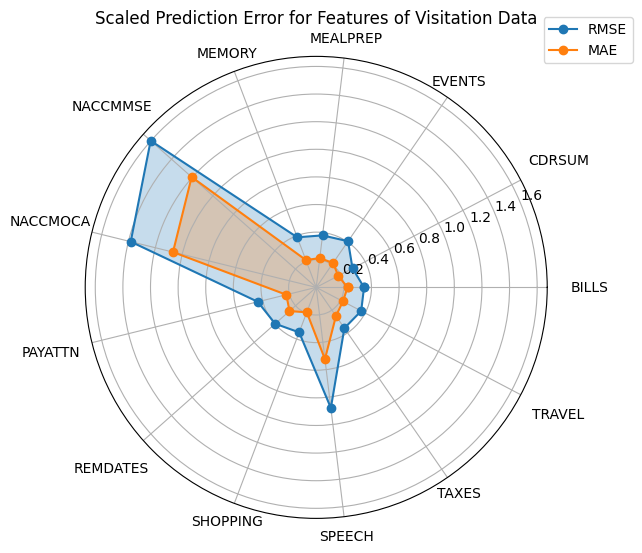

In [45]:
feature_plot(evaluation_result, save_path="plots/evaluation_feature_plot.png")